# **Тема:** Методы выделения признаков в изображениях (HOG, SIFT, SURF, ORB)

---

## 1. Зачем нужны признаки?

В задачах компьютерного зрения изображение представлено как матрица пикселей. Однако работа напрямую с пикселями неудобна:

* один и тот же объект может иметь разный масштаб, ориентацию, освещённость;
* изображения одного класса могут сильно различаться;
* одинаковые изображения могут иметь разные шумы и искажения.

Т.е. входное изображение содержит слишком много дополнительной информации, которая не нужна для дальнейшей классификации. Следовательно, первым шагом в классификации изображений является упрощение изображения путем извлечения важной информации, содержащейся в изображении, и исключения остальной части.

Поэтому вместо «сырых пикселей» используют **признаки** — характеристики, которые описывают изображение более устойчиво.

**Хорошие признаки должны быть:**

* **инвариантны к масштабу** (распознавание объекта независимо от размера);
* **инвариантны к повороту**;
* **устойчивы к изменениям освещения и шуму**;
* **дискриминативны** (различать разные объекты).

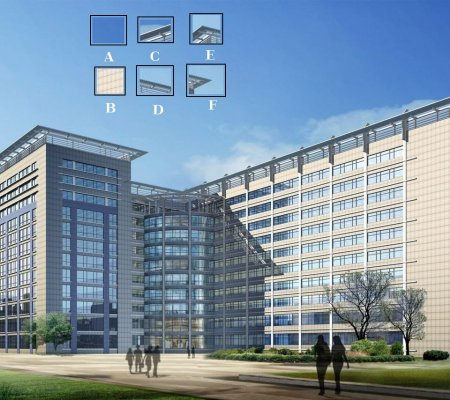 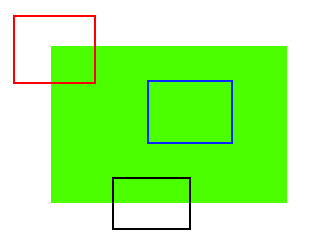

---

## 2. Типы признаков

1. **Глобальные признаки** – описывают всё изображение целиком.

   * Примеры: гистограмма яркости, гистограмма цветовых каналов, HOG.
   * Применение: классификация, распознавание лиц, детекция объектов.

2. **Локальные признаки** – описывают только характерные области изображения (ключевые точки).

   * Примеры: углы, контуры, особые точки, текстуры.
   * Применение: сопоставление изображений, слежение за объектами, построение панорам.

---

## 3. Методы выделения признаков

### 3.1. HOG (Histogram of Oriented Gradients)

* Основан на вычислении направлений градиентов яркости в небольших ячейках изображения.
* Из локальных гистограмм формируется вектор признаков.
* Устойчив к небольшим изменениям освещения и формы.
* Классическое применение — **детектор пешеходов (Dalal & Triggs, 2005)**.

**Схема работы:**

1. Изображение делится на ячейки (например, 8×8 пикселей).
2. Для каждой ячейки считается градиент (направление и величина).
3. Строится гистограмма направлений.
4. Гистограммы нормализуются по блокам.
5. Итоговый вектор используется как дескриптор изображения.

   подробнее: https://waksoft.susu.ru/2021/11/01/histogram-of-oriented-gradients/

---

### 3.2. SIFT (Scale-Invariant Feature Transform)

* Разработан Д. Лоу (1999, 2004).
* Ищет ключевые точки, устойчивые к **масштабу, повороту, освещению**.
* Каждая точка описывается дескриптором (128-мерный вектор).

**Схема работы:**

1. Построение пирамиды гауссовых изображений.
2. Поиск экстремумов в разностных изображениях (DoG).
3. Определение ключевых точек и их ориентации.
4. Формирование дескриптора (гистограммы градиентов в окрестности точки).

**Плюсы:** высокая точность, устойчивость.
**Минусы:** медленный, запатентован (ранее был ограничен в использовании, сейчас открыт).

   подробнее: https://habr.com/ru/articles/516116/

---

### 3.3. SURF (Speeded-Up Robust Features)

* Упрощённый и ускоренный аналог SIFT (Bay, 2006).
* Использует интегральные изображения и аппроксимации гауссовых фильтров.
* Быстрее, но немного менее точный.
* На практике применялся для задач слежения и распознавания.
  
> **На практике:** SURF запатентован и в современных версиях OpenCV **недоступен**
> (модуль `xfeatures2d/nonfree` отключён при сборке). Поэтому в практической части
> сравниваем SIFT и ORB — идея дескрипторов у них та же.

---

### 3.4. ORB (Oriented FAST and Rotated BRIEF)

* Разработан в Google (2011) как бесплатная альтернатива SIFT/SURF.
* Состоит из двух частей:

  * FAST (Features from Accelerated Segment Test) – быстрый детектор углов.
  * BRIEF (Binary Robust Independent Elementary Features) – бинарные дескрипторы.
* Добавлена ориентация, чтобы обеспечить инвариантность к повороту.

**Плюсы:**

* Очень быстрый.
* Бесплатный (open-source).
* Хорошо работает в реальных приложениях (робототехника, AR, SLAM).

**Минусы:**

* Менее точный, чем SIFT при сильных изменениях.

подробнее: https://habr.com/ru/articles/414459/

---

## 4. Сравнение методов

| Метод    | Тип признаков | Инвариантность                | Скорость      | Применение                                |
| -------- | ------------- | ----------------------------- | ------------- | ----------------------------------------- |
| **HOG**  | глобальные    | поворот частично, масштаб нет | высокая       | детекция объектов                         |
| **SIFT** | локальные     | масштаб, поворот, освещение   | низкая        | поиск объектов, сопоставление изображений |
| **SURF** | локальные     | масштаб, поворот              | средняя       | трекинг, распознавание                    |
| **ORB**  | локальные     | поворот, масштаб частично     | очень высокая | реальное время, мобильные приложения      |

---

## 5. Применение выделения признаков

* **Распознавание объектов** (например, детекция пешеходов, автомобилей).
* **Сопоставление изображений** (image matching, построение панорам).
* **Отслеживание объектов** в видео (object tracking).
* **Робототехника и AR** – локализация и навигация (SLAM).
* **Медицинская визуализация** – поиск патологий по характерным структурам.

---

## 6. Основные выводы

1. Признаки позволяют эффективно описывать изображения и сопоставлять их.
2. Выбор метода зависит от задачи: точность vs скорость.
3. Глобальные признаки (HOG) удобны для классификации, локальные (SIFT, ORB) — для сопоставления.
4. В реальных приложениях часто используют **комбинацию методов** или **нейросетевые подходы** (например, CNN).

---


In [1]:
!pip install opencv-python matplotlib scikit-image

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try 'pacman -S
    python-xyz', where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Arch-packaged Python package,
    create a virtual environment using 'python -m venv path/to/venv'.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip.
    
    If you wish to install a non-Arch packaged Python application,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. Make sure you have python-pipx
    installed via pacman.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


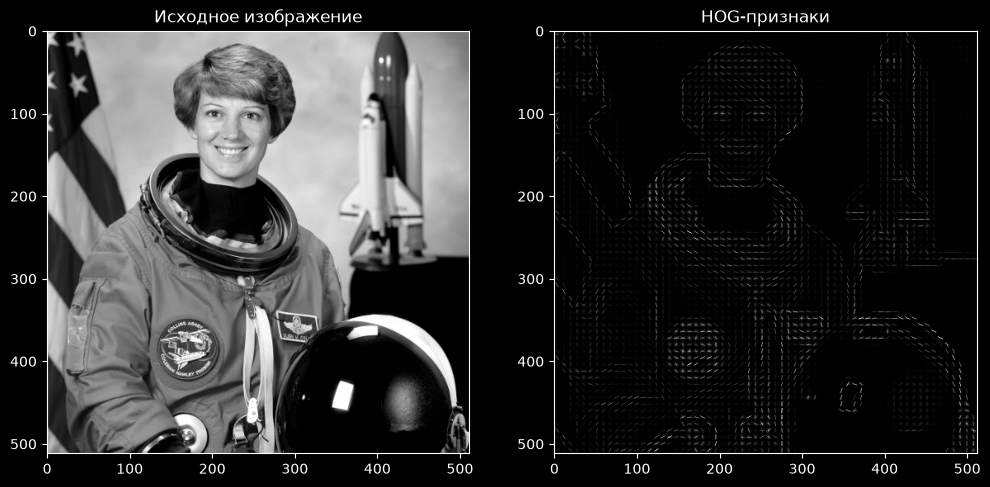

['astronaut',
 'binary_blobs',
 'brain',
 'brick',
 'camera',
 'cat',
 'cell',
 'cells3d',
 'checkerboard',
 'chelsea',
 'clock',
 'coffee',
 'coins',
 'colorwheel',
 'data_dir',
 'download_all',
 'eagle',
 'file_hash',
 'grass',
 'gravel',
 'horse',
 'hubble_deep_field',
 'human_mitosis',
 'immunohistochemistry',
 'kidney',
 'lbp_frontal_face_cascade_filename',
 'lfw_subset',
 'lily',
 'logo',
 'microaneurysms',
 'moon',
 'nickel_solidification',
 'page',
 'palisades_of_vogt',
 'protein_transport',
 'retina',
 'rocket',
 'shepp_logan_phantom',
 'skin',
 'stereo_motorcycle',
 'text',
 'vortex']

In [2]:
#  HOG-признаки
# Загрузить изображение объекта.
# Вычислить HOG-дескриптор и визуализировать.
# Сравнить, как меняется описание при изменении масштаба и поворота.

from skimage.feature import hog
from skimage import data, color, io
import matplotlib.pyplot as plt

image = color.rgb2gray(data.astronaut())
fd, hog_image = hog(image, visualize=True, block_norm='L2-Hys')

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Исходное изображение")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG-признаки")
plt.show()

dir(data)

Найдено ключевых точек: 3802
Размер дескрипторов: (3802, 128)


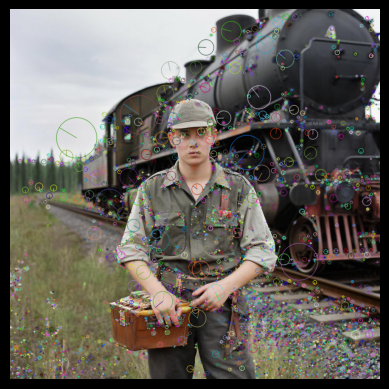

In [3]:
import cv2
import numpy as np

img = cv2.imread('example.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

# Обнаружение ключевых точек и вычисление дескрипторов
keypoints, descriptors = sift.detectAndCompute(gray, None)

# Вывод информации
print(f"Найдено ключевых точек: {len(keypoints)}")
if descriptors is not None:
    print(f"Размер дескрипторов: {descriptors.shape}")

# Отображение ключевых точек на изображении
# Флаг DRAW_RICH_KEYPOINTS рисует «богатые» ключевые точки:
# радиус круга ≈ масштаб особенности, линия внутри — её доминирующая ориентация.
img_with_keypoints = cv2.drawKeypoints(
    img, keypoints, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.imshow(cv2.cvtColor(img_with_keypoints, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

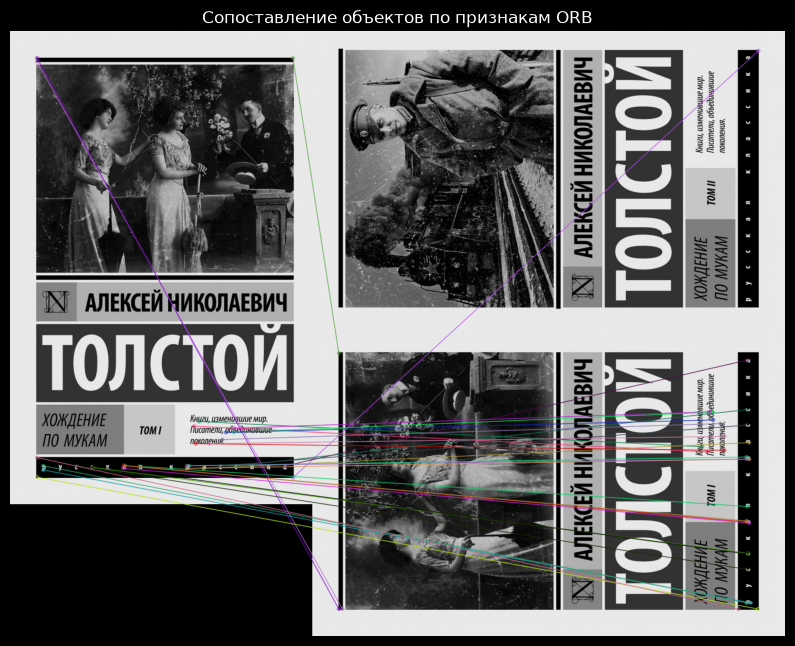

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread('tom1.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('tom2.jpg', cv2.IMREAD_GRAYSCALE)
img2 = np.hstack((img1, img2))
img2 = np.rot90(img2)


orb = cv2.ORB_create()
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

result = cv2.drawMatches(img1, kp1, img2, kp2, matches[:30], None, flags=2)

plt.figure(figsize=(10,10))
plt.imshow(result)
plt.title("Сопоставление объектов по признакам ORB")
plt.axis('off')
plt.show()




## Индивидуальные задания

1. Вычислить HOG для своего изображения и для его повёрнутой копии: сравнить визуализации и размеры дескрипторов.
2. Найти SIFT-ключевые точки на своём фото и нарисовать их; повторить на уменьшенной копии — как меняются количество и положение точек?
3. Сопоставить два своих фото одного объекта (разные ракурсы или расстояния) по ORB с ratio-тестом Лоу; вывести топ-N совпадений и их общее число.

## Индивидуальных задание

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog


def show(images, titles, cmap="gray", figsize=(16, 4)):
    """Выводит несколько изображений в один ряд (как в task_3 / task_4)."""
    fig, ax = plt.subplots(1, len(images), figsize=figsize)
    for a, im, t in zip(ax, images, titles):
        if im.ndim == 2:
            a.imshow(im, cmap=cmap)
        else:
            a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        a.set_title(t)
        a.axis("off")
    plt.tight_layout()
    plt.show()


def unit(v):
    """Нормирует вектор признаков — нужно для косинусного сходства."""
    return v / (np.linalg.norm(v) + 1e-12)


### Задание 1. HOG для своего изображения и для его повёрнутой копии

Размер дескриптора (оригинал) : 46656
Размер дескриптора (поворот 90): 46656
Косинусное сходство           : 0.586
L2-расстояние                : 32.7


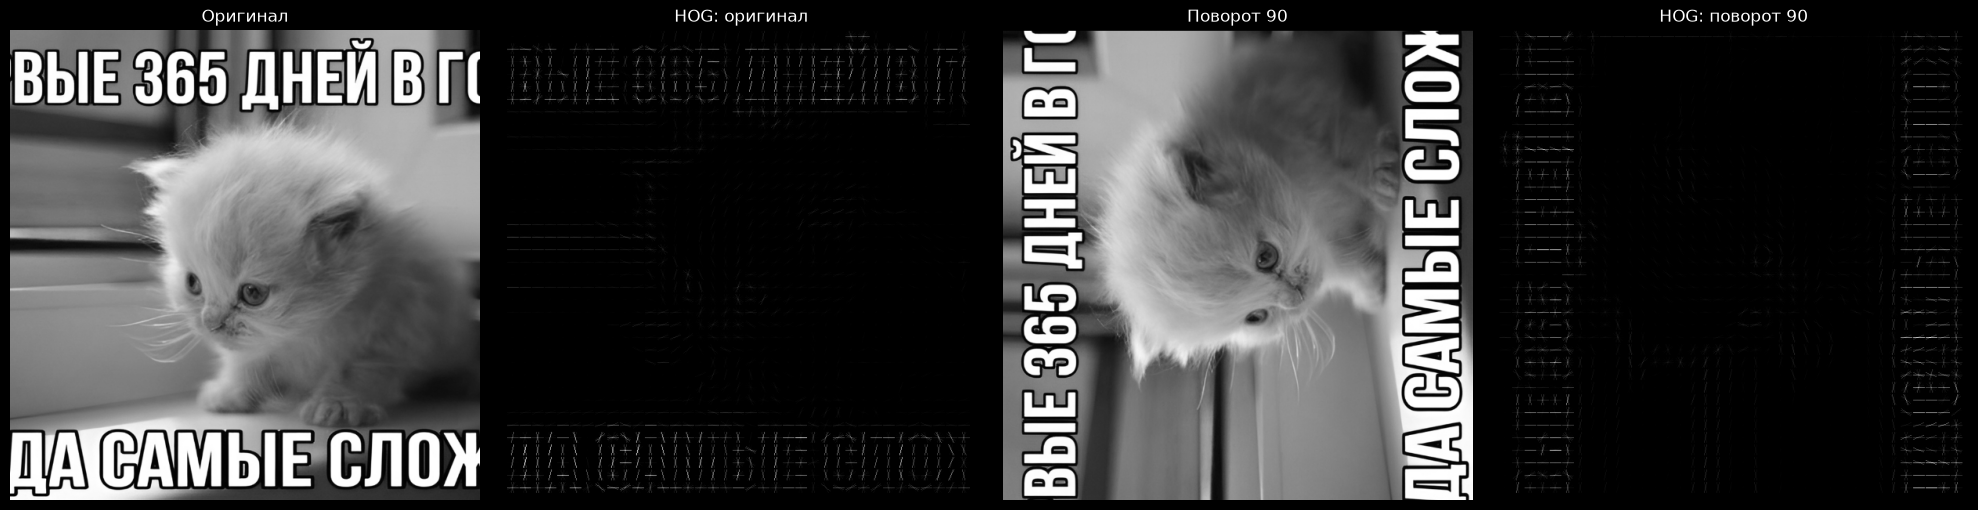

In [12]:
# Квадратный кроп: при повороте на 90° размеры не «переставляются»
img = cv2.imread("image.png", cv2.IMREAD_GRAYSCALE)
h, w = img.shape
s = min(h, w)
cy, cx = h // 2, w // 2
crop = img[cy - s // 2:cy + s // 2, cx - s // 2:cx + s // 2]
crop = cv2.resize(crop, (600, 600))

ORIENT, PPC, CPB = 9, (16, 16), (2, 2)   # число ориентаций, размер ячейки, размер блока


def hog_desc(im, visualize=False):
    return hog(im, orientations=ORIENT, pixels_per_cell=PPC, cells_per_block=CPB,
               block_norm="L2-Hys", feature_vector=True, visualize=visualize)


def rotate(im, angle):
    """Поворот на произвольный угол с сохранением размера картинки."""
    M = cv2.getRotationMatrix2D((im.shape[1] / 2, im.shape[0] / 2), angle, 1.0)
    return cv2.warpAffine(im, M, (im.shape[1], im.shape[0]), flags=cv2.INTER_LINEAR)


rot = rotate(crop, 90)
fd_orig, vis_orig = hog_desc(crop, visualize=True)
fd_rot, vis_rot = hog_desc(rot, visualize=True)

print(f"Размер дескриптора (оригинал) : {fd_orig.shape[0]}")
print(f"Размер дескриптора (поворот 90): {fd_rot.shape[0]}")
print(f"Косинусное сходство           : {unit(fd_orig) @ unit(fd_rot):.3f}")
print(f"L2-расстояние                : {np.linalg.norm(fd_orig - fd_rot):.1f}")

show([crop, vis_orig, rot, vis_rot],
     ["Оригинал", "HOG: оригинал", "Поворот 90", "HOG: поворот 90"],
     figsize=(20, 5))

  поворот   0: сходство 1.000, L2    0.0
  поворот  30: сходство 0.548, L2   33.6
  поворот  45: сходство 0.506, L2   35.1
  поворот  60: сходство 0.521, L2   34.6
  поворот  90: сходство 0.586, L2   32.7
  поворот 135: сходство 0.495, L2   35.4
  поворот 180: сходство 0.686, L2   28.6


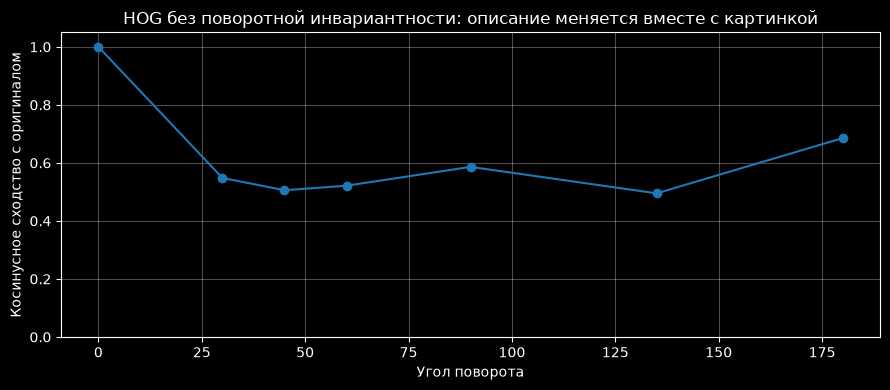

In [13]:
angles = [0, 30, 45, 60, 90, 135, 180]
cos_sim, l2 = [], []

for a in angles:
    fd = hog_desc(rotate(crop, a))
    cos_sim.append(unit(fd_orig) @ unit(fd))
    l2.append(np.linalg.norm(fd_orig - fd))
    print(f"  поворот {a:3d}: сходство {cos_sim[-1]:.3f}, L2 {l2[-1]:6.1f}")

plt.figure(figsize=(9, 4))
plt.plot(angles, cos_sim, "o-", color="tab:blue")
plt.xlabel("Угол поворота")
plt.ylabel("Косинусное сходство с оригиналом")
plt.title("HOG без поворотной инвариантности: описание меняется вместе с картинкой")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Задание 2. SIFT-ключевые точки на своём фото и на уменьшенной копии

Оригинал  1520x916: 1554 точек, дескриптор 128
Копия 0.5x 760x458: 1056 точек, дескриптор 128
Медианный масштаб точки: 5.00 -> 3.19
Найдено пар точек (ratio-test 0.75): 835
Медианное смещение в координатах оригинала: 0.02 % диагонали


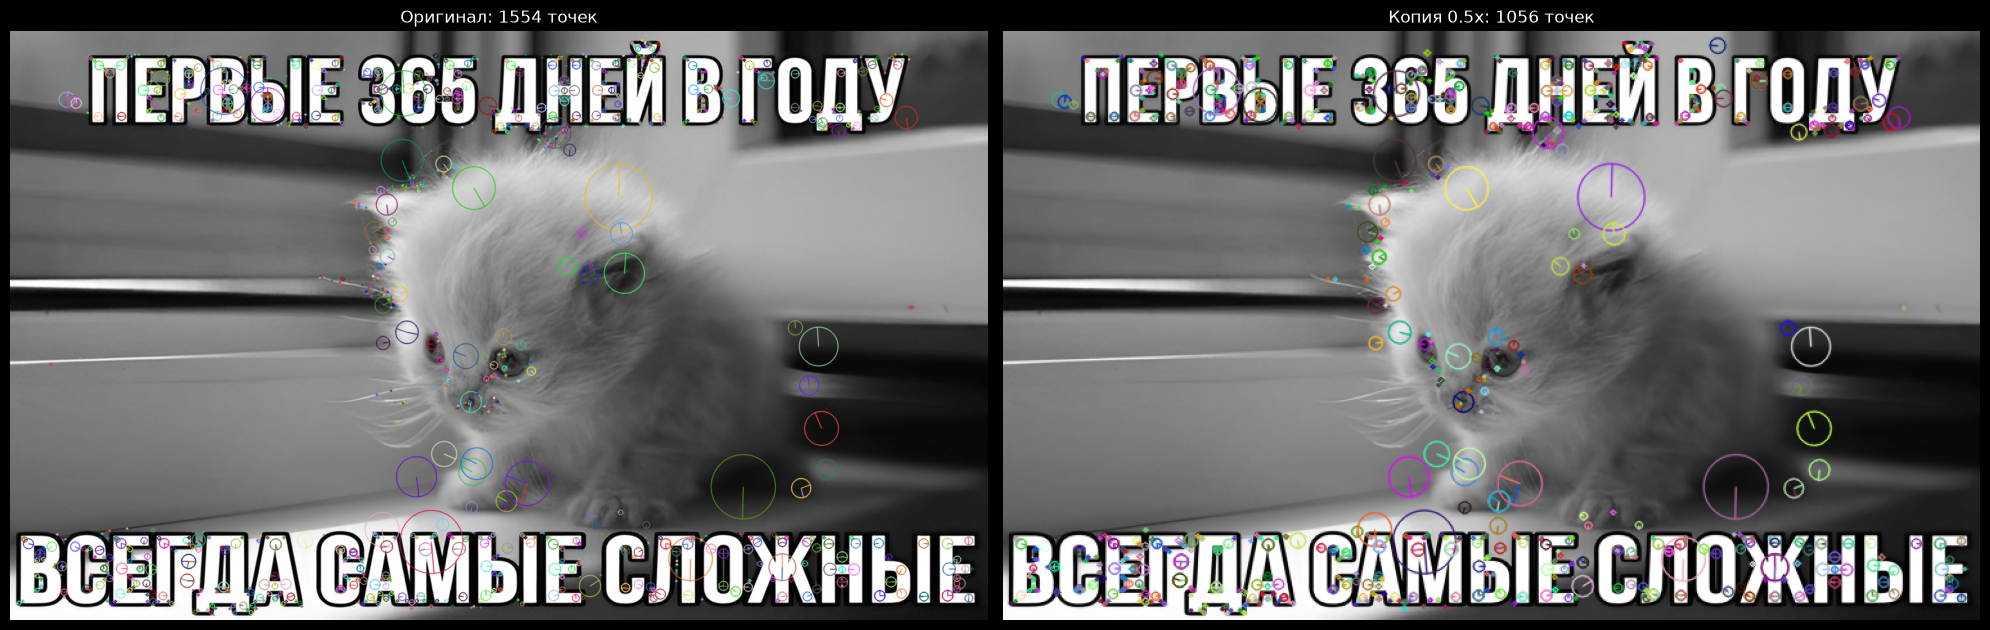

In [14]:
img = cv2.imread("image.png", cv2.IMREAD_GRAYSCALE)
small = cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

sift = cv2.SIFT_create()
kp_full, des_full = sift.detectAndCompute(img, None)
kp_small, des_small = sift.detectAndCompute(small, None)

print(f"Оригинал  {img.shape[1]}x{img.shape[0]}: {len(kp_full)} точек, дескриптор {des_full.shape[1]}")
print(f"Копия 0.5x {small.shape[1]}x{small.shape[0]}: {len(kp_small)} точек, дескриптор {des_small.shape[1]}")
print(f"Медианный масштаб точки: {np.median([k.size for k in kp_full]):.2f} -> "
      f"{np.median([k.size for k in kp_small]):.2f}")

# Переводим координаты уменьшенной копии обратно в масштаб оригинала и сравниваем
RATIO = 0.75
knn = cv2.BFMatcher(cv2.NORM_L2).knnMatch(des_small, des_full, k=2)
good = [p[0] for p in knn if len(p) == 2 and p[0].distance < RATIO * p[1].distance]

diag = np.hypot(*img.shape)
shift = np.array([np.hypot(kp_small[m.queryIdx].pt[0] * 2 - kp_full[m.trainIdx].pt[0],
                           kp_small[m.queryIdx].pt[1] * 2 - kp_full[m.trainIdx].pt[1])
                  for m in good])

print(f"Найдено пар точек (ratio-test {RATIO}): {len(good)}")
print(f"Медианное смещение в координатах оригинала: {np.median(shift) / diag * 100:.2f} % диагонали")

vis_full = cv2.drawKeypoints(img, kp_full, None,
                             flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
vis_small = cv2.drawKeypoints(small, kp_small, None,
                              flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
show([vis_full, vis_small],
     [f"Оригинал: {len(kp_full)} точек", f"Копия 0.5x: {len(kp_small)} точек"],
     figsize=(20, 7))

### Задание 3. Сопоставление двух фото одного объекта по ORB с ratio-тестом Лоу

Ключевых точек: tom1 — 493, tom2 — 1666
Сравнено ключевых точек: 493 (по 2 ближайших кандидата на каждую)
Совпадений после ratio-теста (0.75): 4
Медианная дистанция Хэмминга: 52 бит


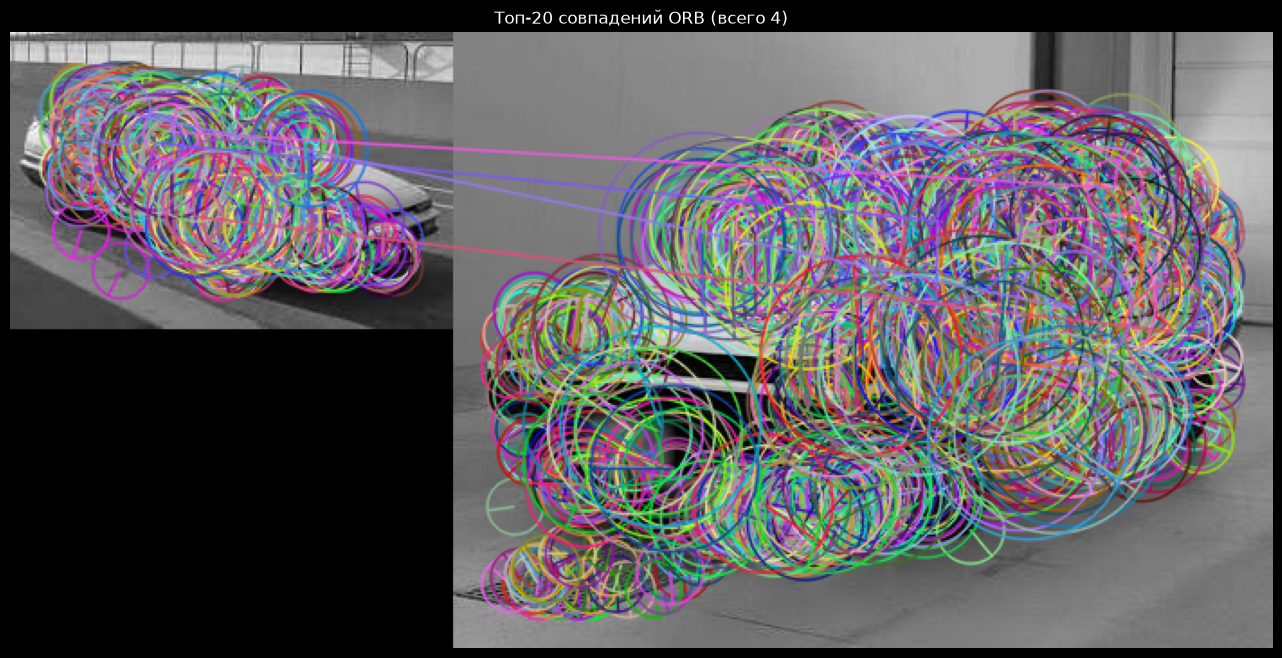

Топ-20 совпадений:
  d= 45.0  tom1(89, 55) -> tom2(367, 86)
  d= 52.0  tom1(80, 61) -> tom2(269, 105)
  d= 52.0  tom1(102, 102) -> tom2(399, 166)
  d= 52.0  tom1(59, 43) -> tom2(344, 153)


In [15]:
img1 = cv2.imread("myimg1.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("myimg2.png", cv2.IMREAD_GRAYSCALE)

orb = cv2.ORB_create(nfeatures=3000)
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)
print(f"Ключевых точек: tom1 — {len(kp1)}, tom2 — {len(kp2)}")

RATIO = 0.75                                   # порог ratio-теста Лоу
bf = cv2.BFMatcher(cv2.NORM_HAMMING)          # для ORB дескрипты бинарные -> Хэмминг
knn = bf.knnMatch(des1, des2, k=2)
good = [p[0] for p in knn if len(p) == 2 and p[0].distance < RATIO * p[1].distance]
good = sorted(good, key=lambda m: m.distance)  # лучшие совпадения — в начало

print(f"Сравнено ключевых точек: {len(knn)} (по 2 ближайших кандидата на каждую)")
print(f"Совпадений после ratio-теста ({RATIO}): {len(good)}")
print(f"Медианная дистанция Хэмминга: {np.median([m.distance for m in good]):.0f} бит")

TOP_N = 20
res = cv2.drawMatches(img1, kp1, img2, kp2, good[:TOP_N], None,
                      flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(20, 8))
plt.imshow(res)
plt.title(f"Топ-{TOP_N} совпадений ORB (всего {len(good)})")
plt.axis("off")
plt.show()

print(f"Топ-{TOP_N} совпадений:")
for m in good[:TOP_N]:
    x1, y1 = kp1[m.queryIdx].pt
    x2, y2 = kp2[m.trainIdx].pt
    print(f"  d={m.distance:5.1f}  tom1({x1:.0f}, {y1:.0f}) -> tom2({x2:.0f}, {y2:.0f})")